In [ ]:
import os

notebook_dir = "/home/balabaevvl/courses/sdc/ysda_sdc/seminar07-ml-planning/homework"

os.chdir(notebook_dir)

GPUs = [
    "GPU-e83bd31b-fcb9-b8de-f617-2d717619413b",
    "GPU-5a9b7750-9f85-49a5-3aae-fe07b1b7661d",
    "GPU-fe2d8dfd-06f2-a5c4-a7fd-4a5f23947005",
    "GPU-0c320096-21ee-4060-8731-826ca2febfab",
    "GPU-baef952c-6609-aace-3b78-e4e07788d5de",
    "GPU-3979d65b-c238-4e9c-0c1c-1aa3f05c56a1",
    "GPU-6c76a2c5-5375-aa06-11d4-0fddfac30e91",
]
os.environ["CUDA_VISIBLE_DEVICES"] = f"{GPUs[2]}"


# Установка пакетов и загрузка данных для ноутбука

Для работы нам понадобится установить пакет `waymax` https://github.com/waymo-research/waymax


Waymax -- симулятор для исследования автономного вождения, базирующийся на `Waymo Open Motion Dataset` https://github.com/waymo-research/waymo-open-dataset

Для обучения сетки будем использовать
`Pytorch Lightning` https://lightning.ai/docs/pytorch/

Для запуска на GPU нужно сменить среду выполнения на Графический процессор

Устанавливаем пакеты:

In [2]:
!pip install --upgrade pip
!pip install git+https://github.com/waymo-research/waymax.git@main#egg=waymo-waymax
!pip install pytorch-lightning==2.5.0

  Cloning https://github.com/waymo-research/waymax.git (to revision main) to /tmp/pip-install-npysxpag/waymo-waymax_56741a145334445c9db9a05f4418c9fb
  Running command git clone --filter=blob:none --quiet https://github.com/waymo-research/waymax.git /tmp/pip-install-npysxpag/waymo-waymax_56741a145334445c9db9a05f4418c9fb
  Resolved https://github.com/waymo-research/waymax.git to commit a64dfec9be8576b60d9cecc94f406d9812d4a7d0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Семпл данных для семинара лежит тут https://disk.yandex.ru/d/IoFBUM-OHDKh4w

**Обратите внимание, архив отличается от архива с семинара наличием тестов и размером датасета**


In [3]:
!rm -f data.tar.gz
!wget -O data.tar.gz "$(curl -s 'https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=https://disk.yandex.ru/d/IoFBUM-OHDKh4w' | python3 -c 'import sys, json; print(json.load(sys.stdin)["href"])')"
!mkdir -p ysda-prediction
!tar -xf data.tar.gz -C ysda-prediction

--2026-05-10 17:49:44--  https://downloader.disk.yandex.ru/disk/1973c0f7644573d21a89625185090c0c3c78f206737e1234541e4edcc47fddb8/6a00fd7a/wwKsipfX-fSAz-6sy8WF7f2Z7hah9KDLA-6IcWYz552EdOOokKUUyb_ttH1JQMe-jiN_9tHSlDFAmJna_M8x5w%3D%3D?uid=0&filename=ysda-prediction-data.tar.gz&disposition=attachment&hash=E924om2pTBgv/leL2WjH4yMhJinTpHIZly2cxh1ybWy7J1eU57iubmUqRo1NwmANq/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&content_type=application%2Fgzip&owner_uid=199924066&fsize=1382522553&hid=3703cf511179500f32518457409692c9&media_type=compressed&tknv=v3
Resolving downloader.disk.yandex.ru (downloader.disk.yandex.ru)... 77.88.21.127, 2a02:6b8::2:127
Connecting to downloader.disk.yandex.ru (downloader.disk.yandex.ru)|77.88.21.127|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://s1065sas.storage.yandex.net/rdisk/1973c0f7644573d21a89625185090c0c3c78f206737e1234541e4edcc47fddb8/6a00fd7a/wwKsipfX-fSAz-6sy8WF7f2Z7hah9KDLA-6IcWYz552EdOOokKUUyb_ttH1JQMe-jiN_9tHSlDFAmJna_M8x5

In [4]:
SEMINAR_PATH = 'ysda-prediction'

Копируем себе в локальное файловое пространство папки с полезными функциями

In [5]:
import os
import shutil

if not os.path.exists('lib'):
    shutil.copytree(os.path.join(SEMINAR_PATH, 'lib'), 'lib')
else:
    print('"lib" folder already exists. If you want to rewrite lib by original folder, remove local "lib" manually')

"lib" folder already exists. If you want to rewrite lib by original folder, remove local "lib" manually


Импортируем библиотеки

In [6]:
%%capture

import os
from copy import deepcopy
from typing import Any, Optional, Callable, Sequence
from collections import defaultdict
import dataclasses

import shapely

import mediapy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import jax
from jax import numpy as jnp
from jax import random

import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger

from waymax.config import DatasetConfig
from waymax import visualization
from waymax import datatypes
from waymax import config as _config
from waymax import dataloader
from waymax import dynamics
from waymax import metrics
from waymax import env as _env
from waymax import agents
from waymax.agents import SimAgentActor, WaymaxActorOutput

import chex

from tqdm import tqdm


from lib.data_utils import WaymaxDataset, scenario_to_features_gt
from lib.tests.tests import test_metrics


# Use CUDA for hw
device = 'cuda'

С помощью следующей функции генерируем конфиг для подгрузки датасета

In [7]:
def get_data_config(split_name, seminar_path=SEMINAR_PATH):
    split_path = os.path.join(SEMINAR_PATH, 'data', split_name)

    obj_count = int(os.listdir(split_path)[0].rsplit('-')[-1])
    return DatasetConfig(
        path=os.path.join(split_path, f'{split_name}_tfexample.tfrecord@{obj_count}'),
        max_num_objects=24,
        batch_dims=[8],
        repeat=1,
        shuffle_buffer_size=64,
        deterministic=False,
        num_shards=1
    )

Создаем датасеты для разных сплитов

In [8]:
train_dataset = WaymaxDataset(get_data_config('training'))
val_dataset = WaymaxDataset(get_data_config('validation'))

In [9]:
FUTURE_STEPS = 30  # Predict 3 seconds,  10Hz frequency

In [10]:
scenario = next(iter(train_dataset))
features, gt = scenario_to_features_gt(scenario)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: (<gast.gast.NamedExpr object at 0x7fe8a408e440>, (leaf_jax_array := getattr(leaf, '__jax_array__', None)))
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7fe9ca396830>: no matching AST found among candidates:
# coding=utf-8
lambda self: self._jaxpr
# coding=utf-8
lambda self: self._consts
# coding=utf-8
lambda self: self._jaxpr.constvars
# coding=utf-8
lambda self: self._jaxpr.invars
# coding=utf-8
lambda self: self._jaxpr.outvars
# coding=utf-8
lambda self: self._jaxpr.eqns
# coding=utf-8
lambda self: self._jaxpr.effects
# coding=utf-8
lambda self: self._jaxpr.debug_info
# coding=utf-8
lambda self: self._jaxpr.is_high
# coding=utf-8
lambda: Var
# coding=utf-8
lambda self: getattr(self.aval, name)
# coding=utf-

### Вcпомогательные функции отрисовки предсказаний модели

Код отрисовки сцены

In [11]:
def plot_states(states, use_log_traj=False, batch_idx=0):
    imgs = []
    for state in states:
        imgs.append(visualization.plot_simulator_state(
            state, use_log_traj=use_log_traj, batch_idx=batch_idx))
    mediapy.show_video(imgs, fps=10)


def extract_best_mode_from_pred_component(pred, best_mode):
    return pred[np.arange(best_mode.shape[0]), best_mode]

def extract_first_timestep_from_pred(pred):
    return pred[..., 0]


# generate open loop prediction with single model run
def generate_open_loop(model, scenario, history_size=11, agent_idx=None):
    states = []

    # some tensors for slicing
    batch_range = jnp.arange(scenario.object_metadata.is_sdc.shape[0])
    control_mask = scenario.object_metadata.is_sdc
    if agent_idx:
        control_mask = jnp.zeros_like(control_mask)
        control_mask = control_mask.at[batch_range, agent_idx].set(True)
        print(f'Control agent with agent_idx = {agent_idx}')
    else:
        print(f'Control ego agent')
    control_indices = control_mask.argmax(-1)

    features, gt = scenario_to_features_gt(
        scenario,
        agent_to_predict_mask=control_mask,
        device=device
    )

    model.to(device)

    # run model
    pred = model(features)
    state = scenario

    # get best mode
    best_mode = pred['logits'].argmax(-1)

    # get best by logit predictions and convert to numpy
    new_x = extract_best_mode_from_pred_component(pred['trajectory']['x'], best_mode).detach().cpu().numpy()
    new_y = extract_best_mode_from_pred_component(pred['trajectory']['y'], best_mode).detach().cpu().numpy()
    new_vel_x = extract_best_mode_from_pred_component(pred['trajectory']['vel_x'], best_mode).detach().cpu().numpy()
    new_vel_y = extract_best_mode_from_pred_component(pred['trajectory']['vel_y'], best_mode).detach().cpu().numpy()
    new_yaw = extract_best_mode_from_pred_component(pred['trajectory']['yaw'], best_mode).detach().cpu().numpy()


    # make 10 steps to make step.timestep equal to first inference timestep
    state = datatypes.update_state_by_log(state, num_steps=10)
    assert (state.timestep == 10).all()


    for _ in range(FUTURE_STEPS):
        # copy log trajectories to sim trajectories for all objects
        state = datatypes.update_state_by_log(state, num_steps=1)

        # rewrite ego sim_trajectory by predictions
        state.sim_trajectory.x = state.sim_trajectory.x.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_x)
        state.sim_trajectory.y = state.sim_trajectory.y.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_y)
        state.sim_trajectory.yaw = state.sim_trajectory.yaw.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_yaw)
        state.sim_trajectory.vel_x = state.sim_trajectory.vel_x.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_vel_x)
        state.sim_trajectory.vel_y = state.sim_trajectory.vel_y.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(new_vel_y)

        state.sim_trajectory.valid = state.sim_trajectory.valid.at[batch_range, control_indices, history_size:history_size+FUTURE_STEPS].set(True)

        states.append(state)

    return states

Код отрисовки мод

In [29]:
def plot_modes(scenario, planner_model, batch_idx):
    # Build features on the same device the model is on, otherwise the first
    # nn.Linear hits "tensors on different devices".
    model_device = next(planner_model.parameters()).device
    features, gt = scenario_to_features_gt(scenario, map_points=2048, device=model_device)
    pred = planner_model(features)

    plt.figure(figsize=(10, 10))

    # draw roadgraph
    rg_points = features['roadgraph_points']
    where_valid = rg_points['valid'][batch_idx]

    rg_x = rg_points['x'][batch_idx][where_valid].detach().cpu()
    rg_y = rg_points['y'][batch_idx][where_valid].detach().cpu()
    types = rg_points['types'][batch_idx][where_valid].detach().cpu()

    plt.scatter(
        x=rg_x,
        y=rg_y,
        s=0.1,
        c=types
    )

    # draw agents
    for agent_idx in range(features['log_trajectory']['x'].shape[-1]):
        x = features['log_trajectory']['x'][batch_idx, agent_idx, -1].detach().cpu().numpy()
        y = features['log_trajectory']['y'][batch_idx, agent_idx, -1].detach().cpu().numpy()
        yaw = features['log_trajectory']['yaw'][batch_idx, agent_idx, -1].detach().cpu().numpy()
        length = features['log_trajectory']['length'][batch_idx, agent_idx, -1].detach().cpu().numpy()
        width = features['log_trajectory']['width'][batch_idx, agent_idx, -1].detach().cpu().numpy()
        valid = features['log_trajectory']['valid'][batch_idx, agent_idx, -1].detach().cpu().numpy()

        is_ego = features['object_metadata']['is_sdc'][batch_idx, agent_idx].detach().cpu().item()

        if not valid:
            continue

        x_corner_offset = length / 2
        y_corner_offset = width / 2

        r = patches.Rectangle(
                xy=(x - x_corner_offset, y - y_corner_offset),
                width=length,
                height=width,
                color='cyan' if is_ego else 'black',
                angle=yaw * 180 / np.pi,
                rotation_point='xy'
            )

        plt.gca().add_patch(r)

    # # draw prediction
    for mode_idx in range(pred['trajectory']['x'].shape[1]):

        plt.scatter(
            pred['trajectory']['x'][batch_idx, mode_idx].detach().cpu().numpy(),
            pred['trajectory']['y'][batch_idx, mode_idx].detach().cpu().numpy(),
            s=5,
            label=f'Mode {mode_idx}'
        )

    scale = 100
    plt.xlim(rg_x.min(), rg_x.max())
    plt.ylim(rg_y.min(), rg_y.max())

    plt.legend()
    plt.show()

# Задания

## 1. Метрики [1 балл]

Для начала реализуем функцию подсчета метрик, нас интересуют `top1_ade` и `min_ade` для предсказываемого агента `gt['agent_to_predict_mask']`. Не забудьте учесть маску видимости агента в гт, усредняем только те таймстемпы, в которые агент наблюдался.

In [13]:
def prediction_metrics(pred, gt):
    agent_to_predict_mask = gt['agent_to_predict_mask']

    # GT for the predicted agent: [bs, T]
    gt_x = gt['log_trajectory']['x'][agent_to_predict_mask]
    gt_y = gt['log_trajectory']['y'][agent_to_predict_mask]
    gt_valid = gt['log_trajectory']['valid'][agent_to_predict_mask].float()

    pred_x = pred['trajectory']['x']  # [bs, n_modes, T]
    pred_y = pred['trajectory']['y']

    dx = pred_x - gt_x.unsqueeze(1)
    dy = pred_y - gt_y.unsqueeze(1)
    dist = torch.sqrt(dx ** 2 + dy ** 2)

    valid = gt_valid.unsqueeze(1)
    T = dist.shape[-1]
    ade_per_mode = (dist * valid).sum(-1) / T  # [bs, n_modes]

    # min_ADE: best mode per scenario
    min_ade = ade_per_mode.min(dim=-1).values.mean()

    # top1_ADE: the mode with the highest logit
    best_mode = pred['logits'].argmax(-1)
    bs = ade_per_mode.shape[0]
    top1_ade = ade_per_mode[torch.arange(bs, device=ade_per_mode.device), best_mode].mean()

    return {
        'min_ade': min_ade,
        'top1_ade': top1_ade,
    }

Тест на 1 балл

In [14]:
test_metrics(prediction_metrics)

Metrics test passed


## 2. Planning модель [9 баллов]

Реализуйте модель для планирования эго-траектории.

**Обязательно переводите в локальную систему координат фичи, которые приходят в сетку, по аналогии с задачей 1 из дз по Prediction. Предсказывайте траектории в локальной системе координат и только потом делайте трансформ в оригинальную систему координат**

Модель должна предсказывать 6 мод по 3 секунды(и вероятности мод) и иметь формат выхода аналогичный с SimpleModel

Баллы за качество:
- min_ade=0.6, top1_ade=1.5 [9 баллов]
- min_ade=0.7, top1_ade=1.75 [7 баллов]
- min_ade=0.8, top1_ade=2.0 [5 балла]

Нужно приложить обучающие кривые (можно скрины) и вывод метрик на валидации. Кроме того, обязательно нарисуйте лучшие предсказания вашей модели(возьмите самые интересные и удачные на ваш взгляд сцены). За отсутствие метрик / кривых / визуализаций будем снимать баллы.

Сохраните чекпоинт для следующей ДЗ, вам предстоит зафайнтюнить его в CL обучении

Пример `SimpleModel`(заведомо плохая модель из-за отсутствия нормализации фичей в локальную систему координат) по аналогии с семинарской моделью, используйте ее формат входа и выхода

In [15]:
class SimpleModel(nn.Module):
    def __init__(
            self,
            n_modes=6,
            future_steps=FUTURE_STEPS,
            hidden_dim=128,
            history_size=11,
    ):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(history_size * 7 + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, future_steps * n_modes * 6 + n_modes)
        )
        self.future_steps = future_steps
        self.n_modes = n_modes

    def __call__(self, features):
        bs, n_a, n_t = features['log_trajectory']['x'].shape

        agents_history = torch.stack(
            [
                features['log_trajectory']['x'],
                features['log_trajectory']['y'],
                features['log_trajectory']['vel_x'],
                features['log_trajectory']['vel_y'],
                features['log_trajectory']['length'],
                features['log_trajectory']['width'],
                features['log_trajectory']['valid'],
            ],
            axis=-1
        )

        agent_history = agents_history[features['agent_to_predict_mask']]
        agent_history = agent_history.reshape(bs, -1)

        agent_type = features['object_metadata']['object_types'][features['agent_to_predict_mask']]
        agent_features = torch.cat(
            [agent_history, agent_type[..., None]], dim=-1)

        res = self.layers(agent_features)

        logits = res[..., -self.n_modes:]
        traj = res[..., :-self.n_modes].reshape(logits.shape[0], self.n_modes, self.future_steps, 6)

        res = {
            'trajectory': {
                'x': traj[..., 0],  # [bs, n_modes, future_steps]
                'y': traj[..., 1],  # [bs, n_modes, future_steps]
                'yaw': torch.atan2(traj[..., 2], traj[..., 3]),  # [bs, n_modes, future_steps]
                'vel_x': traj[..., 4],  # [bs, n_modes, future_steps]
                'vel_y': traj[..., 5]  # [bs, n_modes, future_steps]
            },
            'logits': logits  # [bs, n_modes]
        }

        return res

### Planner модель

Транформерная модель в локальной системе координат эго-агента (на последнем
исторических кадре).

* Признаки агента переводятся в локальную SDC-систему координат (положение и
  скорость поворачиваются на `-yaw_ego`, позиция дополнительно сдвигается на
  `-pos_ego`).
* По каждому агенту (история из 11 кадров) и по каждой точке roadgraph
  собираются токены, прогоняются через self-attention encoder.
* `n_modes` обучаемых query через cross-attention к сцене дают эмбеддинги мод.
* Голова предсказывает `(x, y, vx, vy, sin(yaw), cos(yaw))` в локальной системе,
  затем результаты переводятся обратно в глобальную систему перед возвратом.

In [16]:
class PlannerModel(nn.Module):
    def __init__(
        self,
        n_modes=6,
        future_steps=FUTURE_STEPS,
        hidden_dim=128,
        history_size=11,
        n_heads=4,
        n_history_layers=1,
        n_encoder_layers=3,
        n_decoder_layers=2,
        dropout=0.1,
    ):
        super().__init__()
        self.n_modes = n_modes
        self.future_steps = future_steps
        self.hidden_dim = hidden_dim
        self.history_size = history_size

        # Per-step features in local frame: rx, ry, rvx, rvy, sin(ryaw), cos(ryaw),
        # valid, length, width => 9 dims.
        agent_step_dim = 9
        self.agent_step_proj = nn.Sequential(
            nn.Linear(agent_step_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        self.agent_time_embed = nn.Parameter(torch.randn(history_size, hidden_dim) * 0.02)
        self.history_cls = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        history_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation='gelu',
        )
        self.history_encoder = nn.TransformerEncoder(history_layer, num_layers=n_history_layers)

        self.type_embed = nn.Embedding(8, 16)         # object types -1, 1, 2, 3 (+1 shift)
        self.agent_static_proj = nn.Sequential(
            nn.Linear(16 + 1, hidden_dim),            # type embed + is_ego flag
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        self.agent_fuse = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.map_type_embed = nn.Embedding(22, 16)    # roadgraph types -1..19 (+1 shift)
        self.map_proj = nn.Sequential(
            nn.Linear(4 + 16, hidden_dim),            # rel_x, rel_y, rel_dx, rel_dy + type emb
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.agent_token_type = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        self.map_token_type = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)

        scene_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation='gelu',
        )
        self.scene_encoder = nn.TransformerEncoder(scene_layer, num_layers=n_encoder_layers)

        self.mode_queries = nn.Parameter(torch.randn(n_modes, hidden_dim) * 0.02)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation='gelu',
        )
        self.mode_decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_decoder_layers)

        self.traj_head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, future_steps * 6),  # x, y, vx, vy, sin(yaw), cos(yaw)
        )
        self.logit_head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 1),
        )

    @staticmethod
    def _to_local(x, y, ex, ey, cos_y, sin_y):
        dx = x - ex
        dy = y - ey
        rx = dx * cos_y + dy * sin_y
        ry = -dx * sin_y + dy * cos_y
        return rx, ry

    @staticmethod
    def _rotate(vx, vy, cos_y, sin_y):
        rx = vx * cos_y + vy * sin_y
        ry = -vx * sin_y + vy * cos_y
        return rx, ry

    def forward(self, features):
        device = features['log_trajectory']['x'].device
        bs, n_a, n_t = features['log_trajectory']['x'].shape
        K, H = self.n_modes, self.hidden_dim

        agent_mask = features['agent_to_predict_mask']
        bidx = torch.arange(bs, device=device)
        pred_idx = agent_mask.float().argmax(dim=-1)

        ex = features['log_trajectory']['x'][bidx, pred_idx, -1]
        ey = features['log_trajectory']['y'][bidx, pred_idx, -1]
        eyaw = features['log_trajectory']['yaw'][bidx, pred_idx, -1]
        cos_y = torch.cos(eyaw)
        sin_y = torch.sin(eyaw)

        traj = features['log_trajectory']
        valid = traj['valid'].float()                                  # [bs, n_a, n_t]

        rx, ry = self._to_local(
            traj['x'], traj['y'],
            ex[:, None, None], ey[:, None, None],
            cos_y[:, None, None], sin_y[:, None, None],
        )
        rvx, rvy = self._rotate(
            traj['vel_x'], traj['vel_y'],
            cos_y[:, None, None], sin_y[:, None, None],
        )
        ryaw = traj['yaw'] - eyaw[:, None, None]

        v3 = valid
        per_step = torch.stack([
            rx * v3, ry * v3, rvx * v3, rvy * v3,
            torch.sin(ryaw) * v3, torch.cos(ryaw) * v3,
            v3, traj['length'] * v3, traj['width'] * v3,
        ], dim=-1)                                                     # [bs, n_a, n_t, 9]

        per_step = self.agent_step_proj(per_step)                      # [bs, n_a, n_t, H]
        per_step = per_step + self.agent_time_embed[None, None]

        per_step = per_step.reshape(bs * n_a, n_t, H)
        cls = self.history_cls.expand(bs * n_a, -1, -1)                # [bs*n_a, 1, H]
        seq = torch.cat([cls, per_step], dim=1)                        # [bs*n_a, 1+n_t, H]

        time_pad = valid.reshape(bs * n_a, n_t) < 0.5
        cls_pad = torch.zeros(bs * n_a, 1, dtype=torch.bool, device=device)
        seq_pad = torch.cat([cls_pad, time_pad], dim=1)                # CLS is never padded
        seq_enc = self.history_encoder(seq, src_key_padding_mask=seq_pad)
        agent_hist = seq_enc[:, 0].reshape(bs, n_a, H)                 # CLS readout

        types = features['object_metadata']['object_types']
        is_ego = features['object_metadata']['is_sdc'].float().unsqueeze(-1)
        type_emb = self.type_embed((types.clamp(min=-1) + 1).long())
        static = self.agent_static_proj(torch.cat([type_emb, is_ego], dim=-1))

        agent_tokens = self.agent_fuse(torch.cat([agent_hist, static], dim=-1))
        agent_tokens = agent_tokens + self.agent_token_type

        ids = features['object_metadata']['ids']
        agent_valid = (ids >= 0) & (valid.sum(-1) > 0)                 # [bs, n_a]

        rg = features['roadgraph_points']
        rg_valid = rg['valid'].float()
        rg_rx, rg_ry = self._to_local(
            rg['x'], rg['y'],
            ex[:, None], ey[:, None],
            cos_y[:, None], sin_y[:, None],
        )
        rg_rdx, rg_rdy = self._rotate(
            rg['dir_x'], rg['dir_y'],
            cos_y[:, None], sin_y[:, None],
        )
        rg_rx = rg_rx * rg_valid
        rg_ry = rg_ry * rg_valid
        rg_rdx = rg_rdx * rg_valid
        rg_rdy = rg_rdy * rg_valid

        rg_type_emb = self.map_type_embed((rg['types'].clamp(min=-1) + 1).long())
        rg_feats = torch.cat([
            rg_rx.unsqueeze(-1), rg_ry.unsqueeze(-1),
            rg_rdx.unsqueeze(-1), rg_rdy.unsqueeze(-1),
            rg_type_emb,
        ], dim=-1)
        map_tokens = self.map_proj(rg_feats) + self.map_token_type
        map_valid = rg_valid > 0.5

        scene = torch.cat([agent_tokens, map_tokens], dim=1)
        scene_valid = torch.cat([agent_valid, map_valid], dim=1)
        scene_pad = ~scene_valid
        scene_enc = self.scene_encoder(scene, src_key_padding_mask=scene_pad)

        mode_q = self.mode_queries.unsqueeze(0).expand(bs, -1, -1)     # [bs, K, H]
        mode_out = self.mode_decoder(
            tgt=mode_q,
            memory=scene_enc,
            memory_key_padding_mask=scene_pad,
        )                                                              # [bs, K, H]

        traj_local = self.traj_head(mode_out).reshape(bs, K, self.future_steps, 6)
        logits = self.logit_head(mode_out).squeeze(-1)                 # [bs, K]

        loc_x = traj_local[..., 0]
        loc_y = traj_local[..., 1]
        loc_vx = traj_local[..., 2]
        loc_vy = traj_local[..., 3]
        loc_yaw = torch.atan2(traj_local[..., 4], traj_local[..., 5])

        cos_g = cos_y[:, None, None]
        sin_g = sin_y[:, None, None]
        glb_x = loc_x * cos_g - loc_y * sin_g + ex[:, None, None]
        glb_y = loc_x * sin_g + loc_y * cos_g + ey[:, None, None]
        glb_vx = loc_vx * cos_g - loc_vy * sin_g
        glb_vy = loc_vx * sin_g + loc_vy * cos_g
        glb_yaw = loc_yaw + eyaw[:, None, None]

        return {
            'trajectory': {
                'x': glb_x,
                'y': glb_y,
                'yaw': glb_yaw,
                'vel_x': glb_vx,
                'vel_y': glb_vy,
            },
            'logits': logits,
        }

Класс для обучения



In [17]:
class PredictionModule(pl.LightningModule):
    def __init__(
        self,
        model,
        loss_components_function,
        metrics_function,
        training_shift_random_generator=lambda : 0,
        training_agent_sampler=lambda scenario: scenario.object_metadata.is_sdc,
        validation_agent_sampler=lambda scenario: scenario.object_metadata.is_sdc,
        map_points=256,
        lr=1e-3
    ):
        super().__init__()
        self.model = model
        self.loss_components_function = loss_components_function
        self.metrics_function = metrics_function
        self.training_shift_random_generator = training_shift_random_generator
        self.training_agent_sampler = training_agent_sampler
        self.validation_agent_sampler = validation_agent_sampler

        self.map_points = map_points
        self.lr = lr

    def log_loss(self, split_name, loss, loss_components, batch_size):
        self.log(
            f'{split_name}/epoch/loss/loss',
            loss.detach().cpu().item(),
            batch_size=batch_size,
            on_epoch=True,
            on_step=False
        )
        for k, v in loss_components.items():
            self.log(
                f'{split_name}/epoch/loss/{k}',
                v.detach().cpu().item(),
                batch_size=batch_size,
                on_epoch=True,
                on_step=False
            )

    def log_metrics(self, split_name, metrics, batch_size):
        for k, v in metrics.items():
            self.log(
                f'{split_name}/epoch/{k}',
                v.detach().cpu().item(),
                batch_size=batch_size,
                on_epoch=True,
                on_step=False
            )

    def step(self, scenario, agent_to_predict_mask, shift=0):
        features, gt = scenario_to_features_gt(
            scenario,
            map_points=self.map_points,
            features_first_timestamp=shift,
            agent_to_predict_mask=agent_to_predict_mask,
            device=self.device)

        pred = self.model(features)

        loss_components = self.loss_components_function(pred, gt)
        loss = sum(loss_components[key] for key in loss_components.keys())
        return pred, gt, loss, loss_components

    @torch.no_grad
    def validation_step(self, scenario, batch_idx):
        agent_to_predict_mask = self.validation_agent_sampler(scenario)

        pred, gt, loss, loss_components = self.step(
            scenario,
            agent_to_predict_mask=agent_to_predict_mask)
        self.log_loss(
            'val', loss, loss_components,
            batch_size=scenario['log_trajectory']['x'].shape[0],
        )
        self.log_metrics(
            'val', self.metrics_function(pred, gt),
            batch_size=scenario['log_trajectory']['x'].shape[0],)

        return loss

    def training_step(self, scenario, batch_idx):
        agent_to_predict_mask = self.training_agent_sampler(scenario)

        pred, gt, loss, loss_components = self.step(
            scenario,
            agent_to_predict_mask=agent_to_predict_mask,
            shift=self.training_shift_random_generator())
        self.log_loss(
            'train', loss, loss_components,
            batch_size=scenario['log_trajectory']['x'].shape[0],
        )
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

Реализуйте лосс для предсказания агента, выделяемого маской `gt['agent_to_predict_mask']`. Не забудьте, что лосс должен включать в себя компоненты не только для позиций и логитов, но и для скорости с углом. Не забудьте учесть маску видимости агента в гт

In [18]:
def planner_loss(pred, gt):
    agent_to_predict_mask = gt['agent_to_predict_mask']

    gt_x = gt['log_trajectory']['x'][agent_to_predict_mask]
    gt_y = gt['log_trajectory']['y'][agent_to_predict_mask]
    gt_vx = gt['log_trajectory']['vel_x'][agent_to_predict_mask]
    gt_vy = gt['log_trajectory']['vel_y'][agent_to_predict_mask]
    gt_yaw = gt['log_trajectory']['yaw'][agent_to_predict_mask]
    gt_valid = gt['log_trajectory']['valid'][agent_to_predict_mask].float()

    pred_x = pred['trajectory']['x']     # [bs, K, T]
    pred_y = pred['trajectory']['y']
    pred_vx = pred['trajectory']['vel_x']
    pred_vy = pred['trajectory']['vel_y']
    pred_yaw = pred['trajectory']['yaw']
    logits = pred['logits']               # [bs, K]

    valid = gt_valid.unsqueeze(1)         # [bs, 1, T]
    eps = 1e-6
    n_valid_per_batch = gt_valid.sum(-1).clamp(min=1.0)  # [bs]

    pos_err = torch.sqrt(
        (pred_x - gt_x.unsqueeze(1)) ** 2 + (pred_y - gt_y.unsqueeze(1)) ** 2 + eps
    )
    ade_per_mode = (pos_err * valid).sum(-1) / n_valid_per_batch.unsqueeze(-1)
    best_mode = ade_per_mode.argmin(dim=-1).detach()      # [bs]

    bs = pred_x.shape[0]
    bidx = torch.arange(bs, device=pred_x.device)
    bx = pred_x[bidx, best_mode]
    by = pred_y[bidx, best_mode]
    bvx = pred_vx[bidx, best_mode]
    bvy = pred_vy[bidx, best_mode]
    byaw = pred_yaw[bidx, best_mode]

    def masked_mean(per_step):  # per_step: [bs, T]
        return (per_step * gt_valid).sum() / gt_valid.sum().clamp(min=1.0)

    pos_loss = masked_mean(
        F.smooth_l1_loss(bx, gt_x, reduction='none')
        + F.smooth_l1_loss(by, gt_y, reduction='none')
    )
    vel_loss = masked_mean(
        F.smooth_l1_loss(bvx, gt_vx, reduction='none')
        + F.smooth_l1_loss(bvy, gt_vy, reduction='none')
    )
    yaw_loss = masked_mean(1.0 - torch.cos(byaw - gt_yaw))


    cls_loss = F.cross_entropy(logits, best_mode)

    return {
        'pos_loss': pos_loss,
        'vel_loss': 0.2 * vel_loss,
        'yaw_loss': 0.5 * yaw_loss,
        'cls_loss': 0.5 * cls_loss,
    }

In [19]:
%reload_ext tensorboard
%tensorboard --logdir=tb_logs/

/usr/local/lib/python3.11/subprocess.py:1123: ResourceWarning: subprocess 873590 is still running
  _warn("subprocess %s is still running" % self.pid,


Инициализируем модуль и тренера.

**Обратите внимание, что по дефолту используется 256 токенов карты, этого может оказаться мало, при необходимости увеличивайте**

In [20]:
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping

planner_model = PlannerModel(
    n_modes=6,
    future_steps=FUTURE_STEPS,
    hidden_dim=128,
    history_size=11,
    n_heads=4,
    n_history_layers=1,
    n_encoder_layers=3,
    n_decoder_layers=2,
    dropout=0.1,
)

planner = PredictionModule(
    model=planner_model,
    loss_components_function=planner_loss,
    metrics_function=prediction_metrics,
    training_shift_random_generator=lambda: np.random.randint(0, 80 - FUTURE_STEPS + 1),
    training_agent_sampler=lambda x: x.object_metadata.is_sdc,
    validation_agent_sampler=lambda x: x.object_metadata.is_sdc,
    map_points=384,
    lr=3e-4,
)
planner = planner.to(device)

logger = TensorBoardLogger("tb_logs", name="planner_model")
ckpt_cb = ModelCheckpoint(
    dirpath='checkpoints',
    filename='planner-{epoch:02d}-{val/epoch/min_ade:.3f}',
    monitor='val/epoch/min_ade',
    mode='min',
    save_top_k=3,
    save_last=True,
    auto_insert_metric_name=False,
)
lr_cb = LearningRateMonitor(logging_interval='epoch')

early_cb = EarlyStopping(
    monitor='val/epoch/min_ade',
    mode='min',
    patience=3,
    min_delta=0.005,
)

trainer = pl.Trainer(
    logger=logger,
    log_every_n_steps=20,
    gradient_clip_val=0.5,
    max_epochs=20,
    callbacks=[ckpt_cb, lr_cb, early_cb],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    precision='bf16-mixed',
    benchmark=True,
)

/home/balabaevvl/courses/venv311/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Запускаем обучение

In [21]:
trainer.fit(model=planner, train_dataloaders=train_dataset, val_dataloaders=val_dataset)

/home/balabaevvl/courses/venv311/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Считаем метрики на валидации

In [22]:
trainer.validate(model=planner, dataloaders=val_dataset)

Validation: |                                                                                                 …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  val/epoch/loss/cls_loss  │    0.4494113326072693     │
│    val/epoch/loss/loss    │    0.9754955768585205     │
│  val/epoch/loss/pos_loss  │    0.4352133274078369     │
│  val/epoch/loss/vel_loss  │    0.08696763217449188    │
│  val/epoch/loss/yaw_loss  │   0.003903144970536232    │
│     val/epoch/min_ade     │     0.644569456577301     │
│    val/epoch/top1_ade     │    1.4364311695098877     │
└───────────────────────────┴───────────────────────────┘

[{'val/epoch/loss/loss': 0.9754955768585205,
  'val/epoch/loss/pos_loss': 0.4352133274078369,
  'val/epoch/loss/vel_loss': 0.08696763217449188,
  'val/epoch/loss/yaw_loss': 0.003903144970536232,
  'val/epoch/loss/cls_loss': 0.4494113326072693,
  'val/epoch/min_ade': 0.644569456577301,
  'val/epoch/top1_ade': 1.4364311695098877}]

In [23]:
os.makedirs('checkpoints', exist_ok=True)
torch.save(planner.model.state_dict(), 'checkpoints/planner_final.pt')
print('Best checkpoint(s):', ckpt_cb.best_k_models)
print('Best val min_ade  :', ckpt_cb.best_model_score.item() if ckpt_cb.best_model_score is not None else None)
print('Saved final state_dict to checkpoints/planner_final.pt')

Best checkpoint(s): {'/home/balabaevvl/courses/sdc/ysda_sdc/seminar07-ml-planning/homework/checkpoints/planner-06-0.717.ckpt': tensor(0.7166, device='cuda:0'), '/home/balabaevvl/courses/sdc/ysda_sdc/seminar07-ml-planning/homework/checkpoints/planner-08-0.630.ckpt': tensor(0.6305, device='cuda:0'), '/home/balabaevvl/courses/sdc/ysda_sdc/seminar07-ml-planning/homework/checkpoints/planner-11-0.652.ckpt': tensor(0.6521, device='cuda:0')}
Best val min_ade  : 0.630486786365509
Saved final state_dict to checkpoints/planner_final.pt


Рисуем предсказания

In [24]:
scenario = next(iter(val_dataset))

In [25]:
# predict ego
states = generate_open_loop(planner.model, scenario)

Control ego agent


In [26]:
plot_states(states, batch_idx=0)

This browser does not support the video tag.


In [27]:
plot_states(states, batch_idx=1)

This browser does not support the video tag.


/home/balabaevvl/courses/venv311/lib/python3.11/site-packages/matplotlib/transforms.py:2866: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  if (not np.isfinite(vmin)) or (not np.isfinite(vmax)):


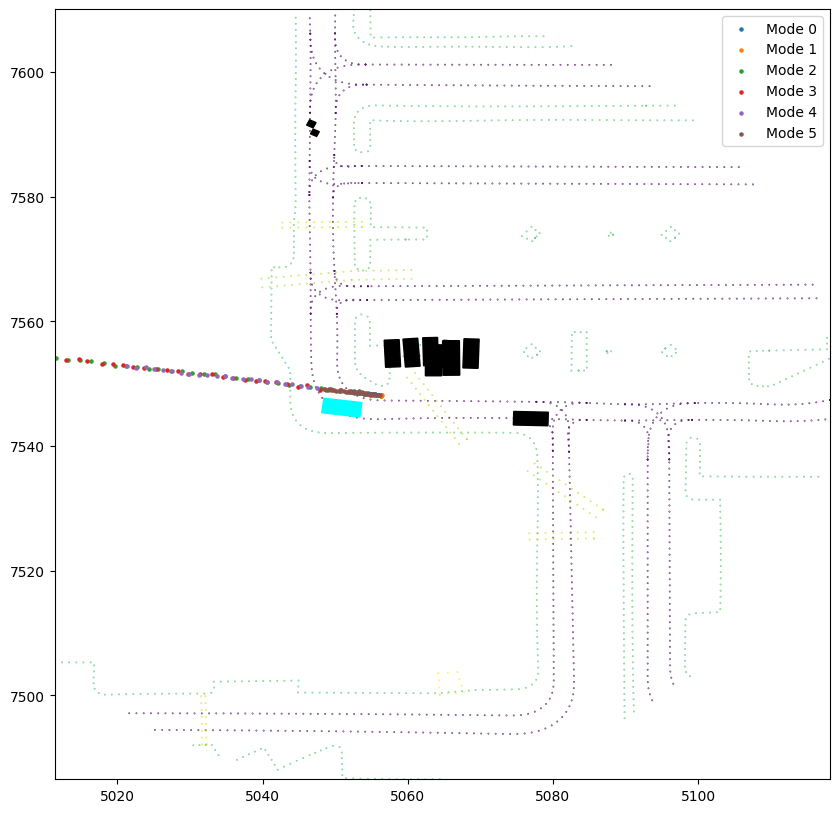

In [30]:
plot_modes(scenario, planner_model, batch_idx=0)

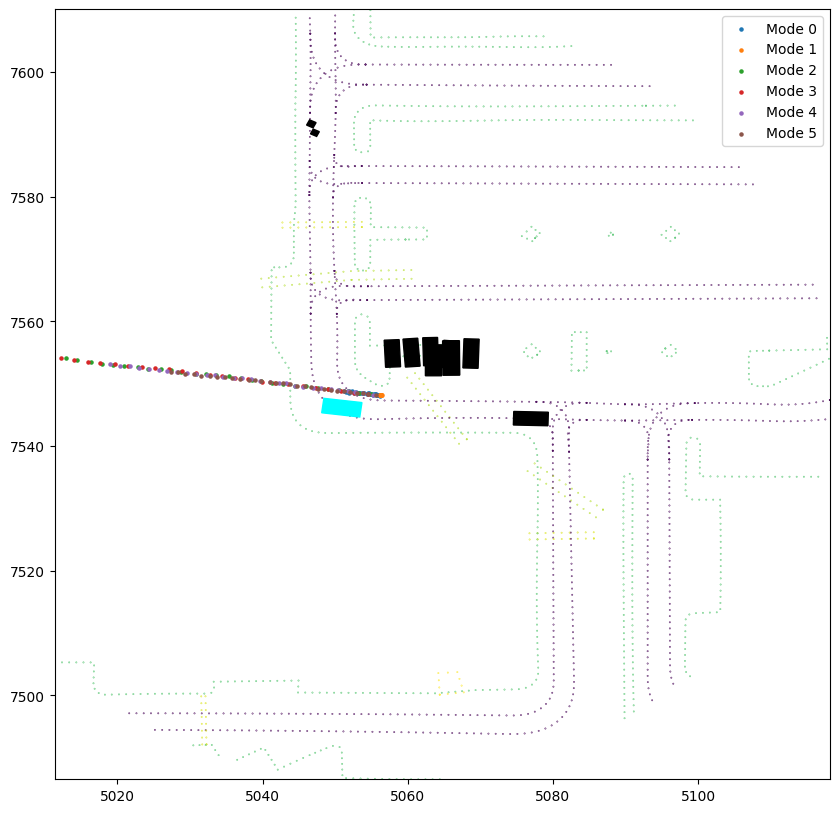

In [31]:
plot_modes(scenario, planner_model, batch_idx=0)

In [ ]:
%tensorboard --logdir=tb_logs/
# у меня бахнулся tb, не рендерит(

Reusing TensorBoard on port 6010 (pid 873590), started 0:25:54 ago. (Use '!kill 873590' to kill it.)